# Notebook 5 — 5 GNN Experiments

**Same GNN model throughout. Only the dataset changes.**

| # | Model | Train data | Test data |
|---|-------|-----------|----------|
| 1 | GNN | CrossDocked original | CrossDocked original |
| 2 | GNN | Your PMDM dataset | Your PMDM dataset |
| 3 | GNN | Your PMDM dataset | CrossDocked original |
| 4 | GNN | CrossDocked original | Your PMDM dataset |
| 5 | GNN | Combined (both) | Combined (both) |

> **Run on T4 GPU:** Runtime → Change runtime type → T4 GPU

In [16]:
# ══════════════════════════════════════════════════════
# CELL 1 — Mount Drive, check required files
# ══════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import pathlib, warnings, subprocess
warnings.filterwarnings('ignore')

BASE      = pathlib.Path('/content/drive/MyDrive/PMDM')
REPO      = BASE / 'repo'
PYTHON    = '/content/micromamba/envs/pmdm/bin/python'
MY_CSV    = BASE / 'dataset' / 'pmdm_dataset.csv'       # your generated dataset
MY_MODEL  = BASE / 'my_model' / 'best_model.pt'          # your trained GNN weights
RESULTS   = BASE / 'experiment_results'
RESULTS.mkdir(exist_ok=True)

SPLIT_PT  = REPO / 'data' / 'split_by_name.pt'
CD_DATA   = REPO / 'data' / 'crossdocked_pocket10'

print('Checking files...')
print(f'  Your CSV       : {"found" if MY_CSV.exists() else "MISSING"} — {MY_CSV}')
print(f'  Your GNN model : {"found" if MY_MODEL.exists() else "MISSING"} — {MY_MODEL}')
print(f'  PMDM repo      : {"found" if REPO.exists() else "MISSING"}')
print(f'  Split file     : {"found" if SPLIT_PT.exists() else "not found (will download)"}')
print(f'  CrossDocked    : {"found" if CD_DATA.exists() else "not found (will extract)"}')

r = subprocess.run(['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'],
                   capture_output=True, text=True)
print(f'\nGPU: {r.stdout.strip() if r.returncode==0 else "CPU only"}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking files...
  Your CSV       : found — /content/drive/MyDrive/PMDM/dataset/pmdm_dataset.csv
  Your GNN model : found — /content/drive/MyDrive/PMDM/my_model/best_model.pt
  PMDM repo      : found
  Split file     : not found (will download)
  CrossDocked    : found

GPU: Tesla T4


In [17]:
# ══════════════════════════════════════════════════════
# CELL 2 — Build CrossDocked CSV (direct, no subprocess)
# ══════════════════════════════════════════════════════
import pathlib, warnings, csv, collections
warnings.filterwarnings('ignore')

BASE    = pathlib.Path('/content/drive/MyDrive/PMDM')
REPO    = BASE / 'repo'
RESULTS = BASE / 'experiment_results'
RESULTS.mkdir(exist_ok=True)
CD_CSV  = RESULTS / 'crossdocked_molecules.csv'

from rdkit import Chem
from rdkit.Chem import Descriptors, QED as Q, rdMolDescriptors

def mol_row(mol, source):
    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd  = Descriptors.NumHDonors(mol)
    hba  = Descriptors.NumHAcceptors(mol)
    qed  = Q.qed(mol)
    lip  = sum([mw<=500, logp<=5, hbd<=5, hba<=10])
    return {"source": source,
            "smiles": Chem.MolToSmiles(mol),
            "qed": round(qed,4), "mw": round(mw,2), "logp": round(logp,3),
            "hbd": hbd, "hba": hba, "lipinski": lip,
            "num_atoms": mol.GetNumAtoms(),
            "num_rings": rdMolDescriptors.CalcNumRings(mol)}

rows = []

# ── Method 1: CrossDocked SDF files ───────────────────
CD_DATA = REPO / 'data' / 'crossdocked_pocket10'
if CD_DATA.exists():
    print(f'Method 1: CrossDocked SDFs at {CD_DATA}')
    sdf_files = sorted(CD_DATA.rglob('*.sdf'))[:5000]
    print(f'  Processing {len(sdf_files)} SDF files...')
    for i, sdf in enumerate(sdf_files):
        if i % 200 == 0: print(f'  {i}/{len(sdf_files)}')
        for mol in Chem.SDMolSupplier(str(sdf), sanitize=False):
            if mol is None: continue
            try:
                Chem.SanitizeMol(mol)
                rows.append(mol_row(mol, 'crossdocked'))
            except: pass
        if len(rows) >= 2000: break
    print(f'  Got {len(rows)} rows from Method 1')

# ── Method 2: PMDM/data folder SDFs ───────────────────
if len(rows) < 50:
    print('Method 2: PMDM data folder SDFs...')
    data_dir = BASE / 'data'
    if data_dir.exists():
        for sdf in data_dir.rglob('*.sdf'):
            for mol in Chem.SDMolSupplier(str(sdf), sanitize=False):
                if mol is None: continue
                try:
                    Chem.SanitizeMol(mol)
                    rows.append(mol_row(mol, 'crossdocked_test'))
                except: pass
    print(f'  Got {len(rows)} rows from Method 2')

# ── Method 3: Zenodo download ──────────────────────────
if len(rows) < 50:
    print('Method 3: Zenodo download...')
    import urllib.request, tarfile
    try:
        url  = 'https://zenodo.org/record/10630921/files/test_set.tar.gz?download=1'
        dest = pathlib.Path('/tmp/test_set.tar.gz')
        if not dest.exists():
            print('  Downloading...')
            urllib.request.urlretrieve(url, dest)
        with tarfile.open(dest) as t:
            t.extractall('/tmp/test_set/')
        for sdf in pathlib.Path('/tmp/test_set').rglob('*.sdf'):
            for mol in Chem.SDMolSupplier(str(sdf), sanitize=False):
                if mol is None: continue
                try:
                    Chem.SanitizeMol(mol)
                    rows.append(mol_row(mol, 'crossdocked_zenodo'))
                except: pass
        print(f'  Got {len(rows)} rows from Method 3')
    except Exception as e:
        print(f'  Zenodo failed: {e}')

# ── Method 4: Drug-like proxy molecules ───────────────
if len(rows) < 50:
    print('Method 4: Drug-like proxy molecules...')
    DRUG_SMILES = [
        "CC(=O)Oc1ccccc1C(=O)O","CC12CCC3C(C1CCC2O)CCC4=CC(=O)CCC34C",
        "CC(C)Cc1ccc(cc1)C(C)C(=O)O","CC(=O)Nc1ccc(O)cc1",
        "OC(=O)c1ccccc1O","CC(=O)c1ccc(cc1)N","Cc1ccc(cc1)S(N)(=O)=O",
        "CN1C=NC2=C1C(=O)N(C(=O)N2C)C","CC(C)(C)NCC(O)c1ccc(O)cc1",
        "OC(=O)c1nc2ccccc2cc1","CC1=CC(=O)c2ccccc2C1=O",
        "Nc1ccc(cc1)S(=O)(=O)N","OC(=O)CNC(=O)c1ccccc1",
        "CC1(C)SC2C(NC(=O)Cc3ccccc3)C(=O)N2C1C(=O)O",
        "CCOc1ccc(cc1)C(=O)OCC","CC(O)(P(=O)(O)O)P(=O)(O)O",
        "OC(=O)c1ccc(O)cc1","CN(C)CCCN1c2ccccc2Sc3ccc(Cl)cc13",
        "CC12CCC3C(C1CCC2=O)CCC4=C3C=CC(=O)4",
        "Oc1ccc(cc1)C2OC3=CC(=O)C=CC3=C2",
        "CC(=O)OCC1OC(=O)C(O)C(O)C1O","CC1C(=O)N(CC(=O)O)C(=O)N1",
        "OCC(O)C(O)C(O)C(O)CO","CC(=O)Nc1ccc(cc1)C(=O)c2ccccc2",
        "OC(=O)CC(O)(CC(=O)O)C(=O)O","CC(=O)Nc1nnc(s1)S(N)(=O)=O",
        "Clc1ccc2c(c1)N(CCN2)C(=O)c3cccc4ccccc34",
        "CC1=C(C(=O)Nc2ccc(cc2)N3CCCC3=O)c4ccccc4N1C",
        "Cc1cc(NC(=O)c2ccc(CN3CCN(CC3)C)cc2)no1",
        "CN(C)c1ccc(cc1)/C=C/C(=O)c2ccc(N(C)C)cc2",
        "CC(=O)Nc1ccc(Cl)c(c1)C(F)(F)F","OC(=O)c1ccncc1",
        "Nc1ccnc2ncnn12","CC(N)Cc1ccccc1","OC(=O)c1ccc(F)cc1",
        "CC1OC(=O)c2ccccc21","CC(=O)c1ccc(O)cc1",
        "CCc1ccc(cc1)C(=O)c2ccccc2",
        "CN1CCN(CC1)c2ccc(Nc3nccc4ccccc34)cc2",
        "Cc1nc2ccc(cc2s1)S(=O)(=O)N3CCCC3",
        "O=C(O)c1ccc(cc1)N2C(=O)C3CC=CCC3C2=O",
        "CC(=O)Nc1ccc(/C=C/C(=O)O)cc1",
        "Cc1ccc(cc1)n2cc(C#N)c(N)n2","OC(=O)c1cccc(O)c1",
        "CC(O)c1ccccc1","Nc1cccc(N)c1"
    ]
    for smi in (DRUG_SMILES * 12)[:500]:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol is None: continue
            rows.append(mol_row(mol, 'crossdocked_proxy'))
        except: pass
    print(f'  Got {len(rows)} rows from Method 4')

# ── Write CSV ──────────────────────────────────────────
if rows:
    with open(CD_CSV, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)
    print(f'\n✓ Saved {len(rows)} molecules → {CD_CSV}')
    for src, cnt in collections.Counter(r['source'] for r in rows).items():
        print(f'  {src}: {cnt}')
else:
    print('ERROR: No molecules collected — check your Drive paths')

print(f'\nCD_CSV exists: {CD_CSV.exists()}')

Method 1: CrossDocked SDFs at /content/drive/MyDrive/PMDM/repo/data/crossdocked_pocket10
  Processing 5000 SDF files...
  0/5000


[10:34:39] Explicit valence for atom # 13 C, 5, is greater than permitted


  200/5000


[10:35:17] Explicit valence for atom # 5 C, 5, is greater than permitted
[10:35:18] Explicit valence for atom # 5 C, 5, is greater than permitted
[10:35:21] Explicit valence for atom # 5 C, 5, is greater than permitted
[10:35:22] Explicit valence for atom # 5 C, 5, is greater than permitted


  400/5000


...

  1400/5000


[10:43:49] Explicit valence for atom # 1 N, 4, is greater than permitted
[10:43:49] Explicit valence for atom # 1 N, 4, is greater than permitted
[10:43:52] Explicit valence for atom # 1 N, 4, is greater than permitted
[10:43:53] Explicit valence for atom # 1 N, 4, is greater than permitted
[10:43:54] Explicit valence for atom # 1 N, 4, is greater than permitted
[10:43:55] Explicit valence for atom # 1 N, 4, is greater than permitted
[10:43:55] Explicit valence for atom # 1 N, 4, is greater than permitted
[10:43:55] Explicit valence for atom # 1 N, 4, is greater than permitted
[10:43:58] Explicit valence for atom # 1 N, 4, is greater than permitted
[10:43:58] Explicit valence for atom # 1 N, 4, is greater than permitted
[10:44:02] Explicit valence for atom # 1 N, 4, is greater than permitted
[10:44:06] Explicit valence for atom # 1 N, 4, is greater than permitted
[10:44:11] Explicit valence for atom # 1 N, 4, is greater than permitted
[10:44:11] Explicit valence for atom # 1 N, 4, is g

  1600/5000
  1800/5000


[10:47:31] Explicit valence for atom # 1 N, 4, is greater than permitted
[10:47:31] Explicit valence for atom # 1 N, 4, is greater than permitted


  2000/5000
  2200/5000
  2400/5000
  Got 2000 rows from Method 1

✓ Saved 2000 molecules → /content/drive/MyDrive/PMDM/experiment_results/crossdocked_molecules.csv
  crossdocked: 2000

CD_CSV exists: True


In [18]:
!pip install rdkit


In [19]:
# ═══════════════════════════════════════════════════════════
# RECOVERY CELL: Restore PMDM Environment
# ═══════════════════════════════════════════════════════════
import os, subprocess

# 1. Install micromamba if missing
if not os.path.exists('/content/micromamba/bin/micromamba'):
    print("Installing micromamba...")
    !curl -Ls https://micro.mamba.pm/api/micromamba/linux-64/latest | tar -xvj bin/micromamba
    !mkdir -p /content/micromamba/bin && mv bin/micromamba /content/micromamba/bin/
    os.environ['MAMBA_ROOT_PREFIX'] = '/content/micromamba'

# 2. Recreate the pmdm environment (fast if already cached )
if not os.path.exists('/content/micromamba/envs/pmdm'):
    print("Recreating pmdm environment... (this may take 5-10 mins)")
    !/content/micromamba/bin/micromamba create -y -n pmdm -c conda-forge python=3.9 rdkit=2023.09.1 openbabel=3.1.1 pip

    # Install required AI libraries
    print("Installing AI libraries...")
    !/content/micromamba/bin/micromamba run -n pmdm pip install -q \
        torch==2.1.1 torchvision==0.16.1 torchaudio==2.1.1 \
        --index-url https://download.pytorch.org/whl/cu118

    !/content/micromamba/bin/micromamba run -n pmdm pip install -q \
        torch-geometric==2.4.0 torch-scatter==2.1.2+pt21cu118 \
        torch-sparse==0.6.18+pt21cu118 torch-cluster==1.6.3+pt21cu118 \
        torch-spline-conv==1.2.2+pt21cu118 \
        -f https://data.pyg.org/whl/torch-2.1.1+cu118.html

    !/content/micromamba/bin/micromamba run -n pmdm pip install -q \
        numpy==1.26.4 scipy pandas tqdm pyyaml einops biopython \
        networkx matplotlib easydict scikit-learn
    print("✓ Environment restored!" )
else:
    print("✓ pmdm environment already exists.")


✓ pmdm environment already exists.


In [20]:
'''# ══════════════════════════════════════════════════════
# CELL 2 — Build CrossDocked CSV (direct, no subprocess)
# ══════════════════════════════════════════════════════
import pathlib, warnings, csv, collections
warnings.filterwarnings('ignore')

BASE    = pathlib.Path('/content/drive/MyDrive/PMDM')
REPO    = BASE / 'repo'
RESULTS = BASE / 'experiment_results'
RESULTS.mkdir(exist_ok=True)
CD_CSV  = RESULTS / 'crossdocked_molecules.csv'

from rdkit import Chem
from rdkit.Chem import Descriptors, QED as Q, rdMolDescriptors

def mol_row(mol, source):
    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd  = Descriptors.NumHDonors(mol)
    hba  = Descriptors.NumHAcceptors(mol)
    qed  = Q.qed(mol)
    lip  = sum([mw<=500, logp<=5, hbd<=5, hba<=10])
    return {"source": source,
            "smiles": Chem.MolToSmiles(mol),
            "qed": round(qed,4), "mw": round(mw,2), "logp": round(logp,3),
            "hbd": hbd, "hba": hba, "lipinski": lip,
            "num_atoms": mol.GetNumAtoms(),
            "num_rings": rdMolDescriptors.CalcNumRings(mol)}

rows = []

# ── Method 1: CrossDocked SDF files ───────────────────
CD_DATA = REPO / 'data' / 'crossdocked_pocket10'
if CD_DATA.exists():
    print(f'Method 1: CrossDocked SDFs at {CD_DATA}')
    sdf_files = sorted(CD_DATA.rglob('*.sdf'))[:2000]
    print(f'  Processing {len(sdf_files)} SDF files...')
    for i, sdf in enumerate(sdf_files):
        if i % 200 == 0: print(f'  {i}/{len(sdf_files)}')
        for mol in Chem.SDMolSupplier(str(sdf), sanitize=False):
            if mol is None: continue
            try:
                Chem.SanitizeMol(mol)
                rows.append(mol_row(mol, 'crossdocked'))
            except: pass
        if len(rows) >= 2000: break
    print(f'  Got {len(rows)} rows from Method 1')

# ── Method 2: PMDM/data folder SDFs ───────────────────
if len(rows) < 50:
    print('Method 2: PMDM data folder SDFs...')
    data_dir = BASE / 'data'
    if data_dir.exists():
        for sdf in data_dir.rglob('*.sdf'):
            for mol in Chem.SDMolSupplier(str(sdf), sanitize=False):
                if mol is None: continue
                try:
                    Chem.SanitizeMol(mol)
                    rows.append(mol_row(mol, 'crossdocked_test'))
                except: pass
    print(f'  Got {len(rows)} rows from Method 2')

# ── Method 3: Zenodo download ──────────────────────────
if len(rows) < 50:
    print('Method 3: Zenodo download...')
    import urllib.request, tarfile
    try:
        url  = 'https://zenodo.org/record/10630921/files/test_set.tar.gz?download=1'
        dest = pathlib.Path('/tmp/test_set.tar.gz')
        if not dest.exists():
            print('  Downloading...')
            urllib.request.urlretrieve(url, dest)
        with tarfile.open(dest) as t:
            t.extractall('/tmp/test_set/')
        for sdf in pathlib.Path('/tmp/test_set').rglob('*.sdf'):
            for mol in Chem.SDMolSupplier(str(sdf), sanitize=False):
                if mol is None: continue
                try:
                    Chem.SanitizeMol(mol)
                    rows.append(mol_row(mol, 'crossdocked_zenodo'))
                except: pass
        print(f'  Got {len(rows)} rows from Method 3')
    except Exception as e:
        print(f'  Zenodo failed: {e}')

# ── Method 4: Drug-like proxy molecules ───────────────
if len(rows) < 50:
    print('Method 4: Drug-like proxy molecules...')
    DRUG_SMILES = [
        "CC(=O)Oc1ccccc1C(=O)O","CC12CCC3C(C1CCC2O)CCC4=CC(=O)CCC34C",
        "CC(C)Cc1ccc(cc1)C(C)C(=O)O","CC(=O)Nc1ccc(O)cc1",
        "OC(=O)c1ccccc1O","CC(=O)c1ccc(cc1)N","Cc1ccc(cc1)S(N)(=O)=O",
        "CN1C=NC2=C1C(=O)N(C(=O)N2C)C","CC(C)(C)NCC(O)c1ccc(O)cc1",
        "OC(=O)c1nc2ccccc2cc1","CC1=CC(=O)c2ccccc2C1=O",
        "Nc1ccc(cc1)S(=O)(=O)N","OC(=O)CNC(=O)c1ccccc1",
        "CC1(C)SC2C(NC(=O)Cc3ccccc3)C(=O)N2C1C(=O)O",
        "CCOc1ccc(cc1)C(=O)OCC","CC(O)(P(=O)(O)O)P(=O)(O)O",
        "OC(=O)c1ccc(O)cc1","CN(C)CCCN1c2ccccc2Sc3ccc(Cl)cc13",
        "CC12CCC3C(C1CCC2=O)CCC4=C3C=CC(=O)4",
        "Oc1ccc(cc1)C2OC3=CC(=O)C=CC3=C2",
        "CC(=O)OCC1OC(=O)C(O)C(O)C1O","CC1C(=O)N(CC(=O)O)C(=O)N1",
        "OCC(O)C(O)C(O)C(O)CO","CC(=O)Nc1ccc(cc1)C(=O)c2ccccc2",
        "OC(=O)CC(O)(CC(=O)O)C(=O)O","CC(=O)Nc1nnc(s1)S(N)(=O)=O",
        "Clc1ccc2c(c1)N(CCN2)C(=O)c3cccc4ccccc34",
        "CC1=C(C(=O)Nc2ccc(cc2)N3CCCC3=O)c4ccccc4N1C",
        "Cc1cc(NC(=O)c2ccc(CN3CCN(CC3)C)cc2)no1",
        "CN(C)c1ccc(cc1)/C=C/C(=O)c2ccc(N(C)C)cc2",
        "CC(=O)Nc1ccc(Cl)c(c1)C(F)(F)F","OC(=O)c1ccncc1",
        "Nc1ccnc2ncnn12","CC(N)Cc1ccccc1","OC(=O)c1ccc(F)cc1",
        "CC1OC(=O)c2ccccc21","CC(=O)c1ccc(O)cc1",
        "CCc1ccc(cc1)C(=O)c2ccccc2",
        "CN1CCN(CC1)c2ccc(Nc3nccc4ccccc34)cc2",
        "Cc1nc2ccc(cc2s1)S(=O)(=O)N3CCCC3",
        "O=C(O)c1ccc(cc1)N2C(=O)C3CC=CCC3C2=O",
        "CC(=O)Nc1ccc(/C=C/C(=O)O)cc1",
        "Cc1ccc(cc1)n2cc(C#N)c(N)n2","OC(=O)c1cccc(O)c1",
        "CC(O)c1ccccc1","Nc1cccc(N)c1"
    ]
    for smi in (DRUG_SMILES * 12)[:500]:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol is None: continue
            rows.append(mol_row(mol, 'crossdocked_proxy'))
        except: pass
    print(f'  Got {len(rows)} rows from Method 4')

# ── Write CSV ──────────────────────────────────────────
if rows:
    with open(CD_CSV, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)
    print(f'\n✓ Saved {len(rows)} molecules → {CD_CSV}')
    for src, cnt in collections.Counter(r['source'] for r in rows).items():
        print(f'  {src}: {cnt}')
else:
    print('ERROR: No molecules collected — check your Drive paths')

print(f'\nCD_CSV exists: {CD_CSV.exists()}')'''

'# ══════════════════════════════════════════════════════\n# CELL 2 — Build CrossDocked CSV (direct, no subprocess)\n# ══════════════════════════════════════════════════════\nimport pathlib, warnings, csv, collections\nwarnings.filterwarnings(\'ignore\')\n\nBASE    = pathlib.Path(\'/content/drive/MyDrive/PMDM\')\nREPO    = BASE / \'repo\'\nRESULTS = BASE / \'experiment_results\'\nRESULTS.mkdir(exist_ok=True)\nCD_CSV  = RESULTS / \'crossdocked_molecules.csv\'\n\nfrom rdkit import Chem\nfrom rdkit.Chem import Descriptors, QED as Q, rdMolDescriptors\n\ndef mol_row(mol, source):\n    mw   = Descriptors.MolWt(mol)\n    logp = Descriptors.MolLogP(mol)\n    hbd  = Descriptors.NumHDonors(mol)\n    hba  = Descriptors.NumHAcceptors(mol)\n    qed  = Q.qed(mol)\n    lip  = sum([mw<=500, logp<=5, hbd<=5, hba<=10])\n    return {"source": source,\n            "smiles": Chem.MolToSmiles(mol),\n            "qed": round(qed,4), "mw": round(mw,2), "logp": round(logp,3),\n            "hbd": hbd, "hba": hb

In [21]:
# ══════════════════════════════════════════════════════
# CELL 3 — Shared code: atom features, GNN model,
#          data loaders, train/eval helpers
#
# THIS CELL IS USED BY ALL 5 EXPERIMENTS UNCHANGED.
# The model architecture never changes — only datasets.
# ══════════════════════════════════════════════════════
import pathlib, json, warnings
warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from rdkit import Chem
from rdkit.Chem import Descriptors, QED as Q, rdMolDescriptors

BASE      = pathlib.Path('/content/drive/MyDrive/PMDM')
MY_CSV    = BASE / 'dataset' / 'pmdm_dataset.csv'
CD_CSV    = BASE / 'experiment_results' / 'crossdocked_molecules.csv'
MY_MODEL  = BASE / 'my_model' / 'best_model.pt'
RESULTS   = BASE / 'experiment_results'
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED      = 42
EPOCHS    = 150
BATCH     = 64
print(f'Device: {DEVICE}')

# ── Atom features ──────────────────────────────────────
ATOM_TYPES = ['C','N','O','F','S','Cl','Br','P','I','Other']
HYBS       = ['SP','SP2','SP3','OTHER']

def atom_feat(a):
    sym = a.GetSymbol()
    at  = [sym == x for x in ATOM_TYPES[:-1]] + [sym not in ATOM_TYPES[:-1]]
    hy  = str(a.GetHybridization()).split('.')[-1]
    hf  = [hy == h for h in HYBS]
    return at + hf + [
        a.GetDegree()/6, a.GetFormalCharge()/4,
        float(a.GetIsAromatic()), float(a.IsInRing()),
        a.GetTotalNumHs()/4, a.GetMass()/120
    ]

FDIM = len(atom_feat(Chem.MolFromSmiles('C').GetAtomWithIdx(0)))

def to_graph(smi):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None: return None, None
    x  = torch.tensor([atom_feat(a) for a in mol.GetAtoms()], dtype=torch.float)
    edges = [[b.GetBeginAtomIdx(), b.GetEndAtomIdx()] for b in mol.GetBonds()]
    edges += [[j, i] for i, j in edges]
    ei = (torch.tensor(edges, dtype=torch.long).t().contiguous()
          if edges else torch.zeros((2,0), dtype=torch.long))
    return x, ei

# ── GNN Model (identical for all experiments) ──────────
class GCNLayer(nn.Module):
    def __init__(self, h):
        super().__init__()
        self.lin = nn.Linear(h, h)
        self.bn  = nn.BatchNorm1d(h)
    def forward(self, x, ei, n):
        agg = torch.zeros(n, x.size(1), device=x.device)
        if ei.numel() > 0:
            agg.index_add_(0, ei[0], x[ei[1]])
            deg = torch.zeros(n, 1, device=x.device)
            deg.index_add_(0, ei[0], torch.ones(ei.size(1), 1, device=x.device))
            agg = agg / deg.clamp(min=1)
        out = self.lin(x + agg)
        return F.relu(self.bn(out) if out.size(0) > 1 else out)

class MolGNN(nn.Module):
    """4-layer GCN — architecture fixed for all 5 experiments."""
    def __init__(self, fd=FDIM, h=128, nl=4):
        super().__init__()
        self.proj  = nn.Linear(fd, h)
        self.convs = nn.ModuleList([GCNLayer(h) for _ in range(nl)])
        self.drop  = nn.Dropout(0.2)
        self.head  = nn.Sequential(
            nn.Linear(h, h//2), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(h//2, 1), nn.Sigmoid()
        )
    def forward(self, x, ei, bi):
        n  = x.size(0); x = F.relu(self.proj(x))
        for cv in self.convs: x = cv(x, ei, n); x = self.drop(x)
        nb   = bi.max().item() + 1
        pool = torch.zeros(nb, x.size(1), device=x.device)
        cnt  = torch.zeros(nb, 1, device=x.device)
        pool.index_add_(0, bi, x)
        cnt.index_add_(0, bi, torch.ones(n, 1, device=x.device))
        return self.head(pool / cnt.clamp(min=1)).squeeze(1)

def make_batch(graphs, targets_list, idxs):
    xs, eis, bs, ys = [], [], [], []; off = 0
    for b, i in enumerate(idxs):
        x, ei = graphs[i]; n = x.size(0)
        xs.append(x)
        eis.append(ei + off if ei.numel() > 0 else ei)
        bs.append(torch.full((n,), b, dtype=torch.long))
        ys.append(targets_list[i]); off += n
    ei_cat = (torch.cat([e for e in eis if e.numel() > 0], 1)
              if any(e.numel() > 0 for e in eis)
              else torch.zeros((2,0), dtype=torch.long))
    return (torch.cat(xs), ei_cat, torch.cat(bs),
            torch.tensor(ys, dtype=torch.float))

# ── Data loading ───────────────────────────────────────
def load_csv_graphs(csv_path, max_rows=None, label=''):
    """Load CSV → list of (node_features, edge_index) graphs + QED targets."""
    df = pd.read_csv(csv_path)
    if 'valid' in df.columns:
        df['valid'] = df['valid'].astype(str).str.lower().map(
            {'true':True,'false':False,'1':True,'0':False}).fillna(False)
        df = df[df['valid'] == True]
    df = df.dropna(subset=['smiles','qed'])
    df = df[df['qed'] > 0].reset_index(drop=True)
    if max_rows:
        df = df.sample(min(max_rows, len(df)), random_state=SEED)
    graphs, targets = [], []
    for _, row in df.iterrows():
        x, ei = to_graph(row['smiles'])
        if x is not None and x.size(0) > 0:
            graphs.append((x, ei))
            targets.append(float(row['qed']))
    tag = label or csv_path.name
    print(f'  [{tag}] Loaded {len(graphs)} valid molecules')
    return graphs, targets

# ── Training & evaluation ──────────────────────────────
def train_gnn(train_graphs, train_targets, val_graphs, val_targets,
              epochs=EPOCHS, label=''):
    """Train a FRESH GNN from scratch. Architecture is always MolGNN."""
    model = MolGNN().to(DEVICE)
    opt   = Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    sched = ReduceLROnPlateau(opt, patience=8, factor=0.5, min_lr=1e-5)
    best_val, best_state = float('inf'), None
    all_tr = list(range(len(train_graphs)))
    all_va = list(range(len(val_graphs)))
    for ep in range(1, epochs+1):
        model.train()
        np.random.shuffle(all_tr)
        tl = []
        for i in range(0, len(all_tr), BATCH):
            x, ei, bi, y = make_batch(train_graphs, train_targets, all_tr[i:i+BATCH])
            x,ei,bi,y = x.to(DEVICE),ei.to(DEVICE),bi.to(DEVICE),y.to(DEVICE)
            opt.zero_grad()
            loss = F.mse_loss(model(x,ei,bi), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); tl.append(loss.item())
        model.eval()
        vp, vt = [], []
        with torch.no_grad():
            for i in range(0, len(all_va), BATCH):
                x,ei,bi,y = make_batch(val_graphs,val_targets,all_va[i:i+BATCH])
                vp += model(x.to(DEVICE),ei.to(DEVICE),bi.to(DEVICE)).cpu().tolist()
                vt += y.tolist()
        vl = mean_absolute_error(vt, vp)
        sched.step(vl)
        if vl < best_val:
            best_val = vl; best_state = model.state_dict()
        if ep % 20 == 0 or ep == 1:
            print(f'    [{label}] Epoch {ep:3d}  val_mae={vl:.4f}  best={best_val:.4f}')
    model.load_state_dict(best_state)
    print(f'  Training done. Best val MAE: {best_val:.4f}')
    return model

def evaluate_gnn(model, test_graphs, test_targets):
    """Evaluate trained GNN on a test set."""
    model.eval()
    all_preds, all_trues = [], []
    all_idx = list(range(len(test_graphs)))
    with torch.no_grad():
        for i in range(0, len(all_idx), BATCH):
            x,ei,bi,y = make_batch(test_graphs, test_targets, all_idx[i:i+BATCH])
            all_preds += model(x.to(DEVICE),ei.to(DEVICE),bi.to(DEVICE)).cpu().tolist()
            all_trues += y.tolist()
    mae = mean_absolute_error(all_trues, all_preds)
    r2  = r2_score(all_trues, all_preds)
    return mae, r2, all_preds, all_trues

def save_result(fname, exp_dict):
    (RESULTS / fname).write_text(json.dumps(exp_dict, indent=2))
    print(f'  Saved → {fname}')

print(f'✓ All shared functions loaded')
print(f'  Atom feature dim  : {FDIM}')
print(f'  GNN model class   : MolGNN (4-layer GCN, h=128)')
print(f'  MY_CSV exists     : {MY_CSV.exists()}')
print(f'  CrossDocked CSV   : {CD_CSV.exists()}')
print(f'  Pretrained weights: {MY_MODEL.exists()} (not used — all exps train fresh)')

Device: cuda
✓ All shared functions loaded
  Atom feature dim  : 20
  GNN model class   : MolGNN (4-layer GCN, h=128)
  MY_CSV exists     : True
  CrossDocked CSV   : True
  Pretrained weights: True (not used — all exps train fresh)


In [22]:
# ══════════════════════════════════════════════════════
# CELL 4 — EXPERIMENT 1
# GNN: Train on CrossDocked → Test on CrossDocked
# Baseline: how well does the GNN learn the original data?
# ══════════════════════════════════════════════════════
print('='*55)
print('EXPERIMENT 1: GNN  |  CrossDocked → CrossDocked')
print('='*55)

g_cd, t_cd = load_csv_graphs(CD_CSV, label='CrossDocked')

idx = list(range(len(g_cd)))
tr_idx, te_idx = train_test_split(idx, test_size=0.2, random_state=SEED)
tr_idx, va_idx = train_test_split(tr_idx, test_size=0.15, random_state=SEED)

g_tr = [g_cd[i] for i in tr_idx]; t_tr = [t_cd[i] for i in tr_idx]
g_va = [g_cd[i] for i in va_idx]; t_va = [t_cd[i] for i in va_idx]
g_te = [g_cd[i] for i in te_idx]; t_te = [t_cd[i] for i in te_idx]
print(f'Train: {len(g_tr)}  Val: {len(g_va)}  Test: {len(g_te)}')

print('\nTraining GNN...')
gnn_exp1 = train_gnn(g_tr, t_tr, g_va, t_va, epochs=EPOCHS, label='Exp1')

mae_e1, r2_e1, _, _ = evaluate_gnn(gnn_exp1, g_te, t_te)

exp1_result = {
    'experiment' : 'Exp1_GNN_CrossDocked_CrossDocked',
    'model'      : 'GNN (4-layer GCN, h=128)',
    'train_data' : 'CrossDocked original',
    'test_data'  : 'CrossDocked original',
    'n_train'    : len(g_tr),
    'n_test'     : len(g_te),
    'MAE'        : round(mae_e1, 4),
    'R2'         : round(r2_e1, 4)
}
print(f'\n--- EXPERIMENT 1 RESULTS ---')
print(f'Train  : CrossDocked ({len(g_tr)} mols)')
print(f'Test   : CrossDocked ({len(g_te)} mols)')
print(f'MAE    : {mae_e1:.4f}')
print(f'R²     : {r2_e1:.4f}')
save_result('exp1_gnn_cd_cd.json', exp1_result)

EXPERIMENT 1: GNN  |  CrossDocked → CrossDocked
  [CrossDocked] Loaded 2000 valid molecules
Train: 1360  Val: 240  Test: 400

Training GNN...
    [Exp1] Epoch   1  val_mae=0.1658  best=0.1658
    [Exp1] Epoch  20  val_mae=0.0306  best=0.0306
    [Exp1] Epoch  40  val_mae=0.0317  best=0.0258
    [Exp1] Epoch  60  val_mae=0.0208  best=0.0208
    [Exp1] Epoch  80  val_mae=0.0218  best=0.0156
    [Exp1] Epoch 100  val_mae=0.0181  best=0.0153
    [Exp1] Epoch 120  val_mae=0.0183  best=0.0153
    [Exp1] Epoch 140  val_mae=0.0172  best=0.0153
  Training done. Best val MAE: 0.0153

--- EXPERIMENT 1 RESULTS ---
Train  : CrossDocked (1360 mols)
Test   : CrossDocked (400 mols)
MAE    : 0.0204
R²     : 0.9714
  Saved → exp1_gnn_cd_cd.json


In [23]:
# ══════════════════════════════════════════════════════
# CELL 5 — EXPERIMENT 2
# GNN: Train on YOUR dataset → Test on YOUR dataset
# Baseline: how well does the GNN learn your own data?
# ══════════════════════════════════════════════════════
print('='*55)
print('EXPERIMENT 2: GNN  |  Your Data → Your Data')
print('='*55)

g_my, t_my = load_csv_graphs(MY_CSV, label='YourData')

idx = list(range(len(g_my)))
tr_idx, te_idx = train_test_split(idx, test_size=0.2, random_state=SEED)
tr_idx, va_idx = train_test_split(tr_idx, test_size=0.15, random_state=SEED)

g_tr2 = [g_my[i] for i in tr_idx]; t_tr2 = [t_my[i] for i in tr_idx]
g_va2 = [g_my[i] for i in va_idx]; t_va2 = [t_my[i] for i in va_idx]
g_te2 = [g_my[i] for i in te_idx]; t_te2 = [t_my[i] for i in te_idx]
print(f'Train: {len(g_tr2)}  Val: {len(g_va2)}  Test: {len(g_te2)}')

print('\nTraining GNN...')
gnn_exp2 = train_gnn(g_tr2, t_tr2, g_va2, t_va2, epochs=EPOCHS, label='Exp2')

mae_e2, r2_e2, _, _ = evaluate_gnn(gnn_exp2, g_te2, t_te2)

exp2_result = {
    'experiment' : 'Exp2_GNN_MyData_MyData',
    'model'      : 'GNN (4-layer GCN, h=128)',
    'train_data' : 'Your PMDM-generated dataset',
    'test_data'  : 'Your PMDM-generated dataset',
    'n_train'    : len(g_tr2),
    'n_test'     : len(g_te2),
    'MAE'        : round(mae_e2, 4),
    'R2'         : round(r2_e2, 4)
}
print(f'\n--- EXPERIMENT 2 RESULTS ---')
print(f'Train  : Your PMDM data ({len(g_tr2)} mols)')
print(f'Test   : Your PMDM data ({len(g_te2)} mols)')
print(f'MAE    : {mae_e2:.4f}')
print(f'R²     : {r2_e2:.4f}')
save_result('exp2_gnn_my_my.json', exp2_result)

EXPERIMENT 2: GNN  |  Your Data → Your Data
  [YourData] Loaded 134 valid molecules
Train: 90  Val: 17  Test: 27

Training GNN...
    [Exp2] Epoch   1  val_mae=0.1468  best=0.1468
    [Exp2] Epoch  20  val_mae=0.0566  best=0.0566
    [Exp2] Epoch  40  val_mae=0.0739  best=0.0566
    [Exp2] Epoch  60  val_mae=0.0722  best=0.0566
    [Exp2] Epoch  80  val_mae=0.0758  best=0.0566
    [Exp2] Epoch 100  val_mae=0.0756  best=0.0566
    [Exp2] Epoch 120  val_mae=0.0758  best=0.0566
    [Exp2] Epoch 140  val_mae=0.0778  best=0.0566
  Training done. Best val MAE: 0.0566

--- EXPERIMENT 2 RESULTS ---
Train  : Your PMDM data (90 mols)
Test   : Your PMDM data (27 mols)
MAE    : 0.0859
R²     : 0.6429
  Saved → exp2_gnn_my_my.json


In [24]:
# ══════════════════════════════════════════════════════
# CELL 6 — EXPERIMENT 3
# GNN: Train on YOUR dataset → Test on CrossDocked
# Generalization test: can your data teach the GNN
# to predict on real CrossDocked molecules?
# ══════════════════════════════════════════════════════
print('='*55)
print('EXPERIMENT 3: GNN  |  Your Data → CrossDocked')
print('='*55)

# Train split from YOUR data
g_my, t_my = load_csv_graphs(MY_CSV, label='YourData')
idx_my = list(range(len(g_my)))
tr_my, va_my = train_test_split(idx_my, test_size=0.15, random_state=SEED)
g_tr3 = [g_my[i] for i in tr_my]; t_tr3 = [t_my[i] for i in tr_my]
g_va3 = [g_my[i] for i in va_my]; t_va3 = [t_my[i] for i in va_my]

# Full CrossDocked as test set
g_cd, t_cd = load_csv_graphs(CD_CSV, label='CrossDocked')

print(f'Train (your data) : {len(g_tr3)}')
print(f'Test (CrossDocked): {len(g_cd)}')

print('\nTraining GNN...')
gnn_exp3 = train_gnn(g_tr3, t_tr3, g_va3, t_va3, epochs=EPOCHS, label='Exp3')

mae_e3, r2_e3, _, _ = evaluate_gnn(gnn_exp3, g_cd, t_cd)

exp3_result = {
    'experiment' : 'Exp3_GNN_MyData_CrossDocked',
    'model'      : 'GNN (4-layer GCN, h=128)',
    'train_data' : 'Your PMDM-generated dataset',
    'test_data'  : 'CrossDocked original',
    'n_train'    : len(g_tr3),
    'n_test'     : len(g_cd),
    'MAE'        : round(mae_e3, 4),
    'R2'         : round(r2_e3, 4)
}
print(f'\n--- EXPERIMENT 3 RESULTS ---')
print(f'Train  : Your PMDM data ({len(g_tr3)} mols)')
print(f'Test   : CrossDocked   ({len(g_cd)} mols)')
print(f'MAE    : {mae_e3:.4f}')
print(f'R²     : {r2_e3:.4f}')
save_result('exp3_gnn_my_cd.json', exp3_result)

EXPERIMENT 3: GNN  |  Your Data → CrossDocked
  [YourData] Loaded 134 valid molecules
  [CrossDocked] Loaded 2000 valid molecules
Train (your data) : 113
Test (CrossDocked): 2000

Training GNN...
    [Exp3] Epoch   1  val_mae=0.1493  best=0.1493
    [Exp3] Epoch  20  val_mae=0.0994  best=0.0994
    [Exp3] Epoch  40  val_mae=0.0854  best=0.0772
    [Exp3] Epoch  60  val_mae=0.0768  best=0.0757
    [Exp3] Epoch  80  val_mae=0.0800  best=0.0757
    [Exp3] Epoch 100  val_mae=0.0782  best=0.0757
    [Exp3] Epoch 120  val_mae=0.0793  best=0.0757
    [Exp3] Epoch 140  val_mae=0.0777  best=0.0757
  Training done. Best val MAE: 0.0757

--- EXPERIMENT 3 RESULTS ---
Train  : Your PMDM data (113 mols)
Test   : CrossDocked   (2000 mols)
MAE    : 0.1379
R²     : 0.4157
  Saved → exp3_gnn_my_cd.json


In [25]:
# ══════════════════════════════════════════════════════
# CELL 7 — EXPERIMENT 4
# GNN: Train on CrossDocked → Test on YOUR dataset
# Transfer test: vice versa of Experiment 3
# ══════════════════════════════════════════════════════
print('='*55)
print('EXPERIMENT 4: GNN  |  CrossDocked → Your Data')
print('='*55)

# Train split from CrossDocked
g_cd, t_cd = load_csv_graphs(CD_CSV, label='CrossDocked')
idx_cd = list(range(len(g_cd)))
tr_cd, va_cd = train_test_split(idx_cd, test_size=0.15, random_state=SEED)
g_tr4 = [g_cd[i] for i in tr_cd]; t_tr4 = [t_cd[i] for i in tr_cd]
g_va4 = [g_cd[i] for i in va_cd]; t_va4 = [t_cd[i] for i in va_cd]

# Full YOUR data as test set
g_my, t_my = load_csv_graphs(MY_CSV, label='YourData')

print(f'Train (CrossDocked): {len(g_tr4)}')
print(f'Test  (your data)  : {len(g_my)}')

print('\nTraining GNN...')
gnn_exp4 = train_gnn(g_tr4, t_tr4, g_va4, t_va4, epochs=EPOCHS, label='Exp4')

mae_e4, r2_e4, _, _ = evaluate_gnn(gnn_exp4, g_my, t_my)

exp4_result = {
    'experiment' : 'Exp4_GNN_CrossDocked_MyData',
    'model'      : 'GNN (4-layer GCN, h=128)',
    'train_data' : 'CrossDocked original',
    'test_data'  : 'Your PMDM-generated dataset',
    'n_train'    : len(g_tr4),
    'n_test'     : len(g_my),
    'MAE'        : round(mae_e4, 4),
    'R2'         : round(r2_e4, 4)
}
print(f'\n--- EXPERIMENT 4 RESULTS ---')
print(f'Train  : CrossDocked   ({len(g_tr4)} mols)')
print(f'Test   : Your PMDM data ({len(g_my)} mols)')
print(f'MAE    : {mae_e4:.4f}')
print(f'R²     : {r2_e4:.4f}')
save_result('exp4_gnn_cd_my.json', exp4_result)

EXPERIMENT 4: GNN  |  CrossDocked → Your Data
  [CrossDocked] Loaded 2000 valid molecules
  [YourData] Loaded 134 valid molecules
Train (CrossDocked): 1700
Test  (your data)  : 134

Training GNN...
    [Exp4] Epoch   1  val_mae=0.1425  best=0.1425
    [Exp4] Epoch  20  val_mae=0.0309  best=0.0292
    [Exp4] Epoch  40  val_mae=0.0274  best=0.0220
    [Exp4] Epoch  60  val_mae=0.0230  best=0.0195
    [Exp4] Epoch  80  val_mae=0.0192  best=0.0185
    [Exp4] Epoch 100  val_mae=0.0178  best=0.0162
    [Exp4] Epoch 120  val_mae=0.0175  best=0.0162
    [Exp4] Epoch 140  val_mae=0.0183  best=0.0162
  Training done. Best val MAE: 0.0162

--- EXPERIMENT 4 RESULTS ---
Train  : CrossDocked   (1700 mols)
Test   : Your PMDM data (134 mols)
MAE    : 0.1358
R²     : -0.0936
  Saved → exp4_gnn_cd_my.json


In [26]:
# ══════════════════════════════════════════════════════
# CELL 8 — EXPERIMENT 5
# GNN: Train on COMBINED (CrossDocked + Your data)
#      → Test on COMBINED (held-out from both)
# Best of both worlds: does mixing datasets help?
# ══════════════════════════════════════════════════════
print('='*55)
print('EXPERIMENT 5: GNN  |  Combined → Combined')
print('='*55)

# Load both datasets
g_cd, t_cd = load_csv_graphs(CD_CSV, label='CrossDocked')
g_my, t_my = load_csv_graphs(MY_CSV, label='YourData')

# Tag source so we know the split composition
all_graphs  = g_cd + g_my
all_targets = t_cd + t_my
n_combined  = len(all_graphs)
print(f'Combined total: {n_combined}  '
      f'(CrossDocked: {len(g_cd)}, Yours: {len(g_my)})')

# Split combined pool into train / val / test
idx = list(range(n_combined))
tr_idx, te_idx = train_test_split(idx, test_size=0.2, random_state=SEED)
tr_idx, va_idx = train_test_split(tr_idx, test_size=0.15, random_state=SEED)

g_tr5 = [all_graphs[i]  for i in tr_idx]; t_tr5 = [all_targets[i] for i in tr_idx]
g_va5 = [all_graphs[i]  for i in va_idx]; t_va5 = [all_targets[i] for i in va_idx]
g_te5 = [all_graphs[i]  for i in te_idx]; t_te5 = [all_targets[i] for i in te_idx]
print(f'Train: {len(g_tr5)}  Val: {len(g_va5)}  Test: {len(g_te5)}')

print('\nTraining GNN...')
gnn_exp5 = train_gnn(g_tr5, t_tr5, g_va5, t_va5, epochs=EPOCHS, label='Exp5')

mae_e5, r2_e5, _, _ = evaluate_gnn(gnn_exp5, g_te5, t_te5)

exp5_result = {
    'experiment' : 'Exp5_GNN_Combined_Combined',
    'model'      : 'GNN (4-layer GCN, h=128)',
    'train_data' : f'Combined (CrossDocked + PMDM)',
    'test_data'  : f'Combined (CrossDocked + PMDM)',
    'n_cd'       : len(g_cd),
    'n_my'       : len(g_my),
    'n_train'    : len(g_tr5),
    'n_test'     : len(g_te5),
    'MAE'        : round(mae_e5, 4),
    'R2'         : round(r2_e5, 4)
}
print(f'\n--- EXPERIMENT 5 RESULTS ---')
print(f'Train  : Combined ({len(g_tr5)} mols)')
print(f'Test   : Combined ({len(g_te5)} mols)')
print(f'MAE    : {mae_e5:.4f}')
print(f'R²     : {r2_e5:.4f}')
save_result('exp5_gnn_combined.json', exp5_result)

EXPERIMENT 5: GNN  |  Combined → Combined
  [CrossDocked] Loaded 2000 valid molecules
  [YourData] Loaded 134 valid molecules
Combined total: 2134  (CrossDocked: 2000, Yours: 134)
Train: 1450  Val: 257  Test: 427

Training GNN...
    [Exp5] Epoch   1  val_mae=0.1203  best=0.1203
    [Exp5] Epoch  20  val_mae=0.0417  best=0.0417
    [Exp5] Epoch  40  val_mae=0.0415  best=0.0342
    [Exp5] Epoch  60  val_mae=0.0281  best=0.0273
    [Exp5] Epoch  80  val_mae=0.0254  best=0.0243
    [Exp5] Epoch 100  val_mae=0.0235  best=0.0226
    [Exp5] Epoch 120  val_mae=0.0232  best=0.0216
    [Exp5] Epoch 140  val_mae=0.0223  best=0.0216
  Training done. Best val MAE: 0.0216

--- EXPERIMENT 5 RESULTS ---
Train  : Combined (1450 mols)
Test   : Combined (427 mols)
MAE    : 0.0239
R²     : 0.9536
  Saved → exp5_gnn_combined.json


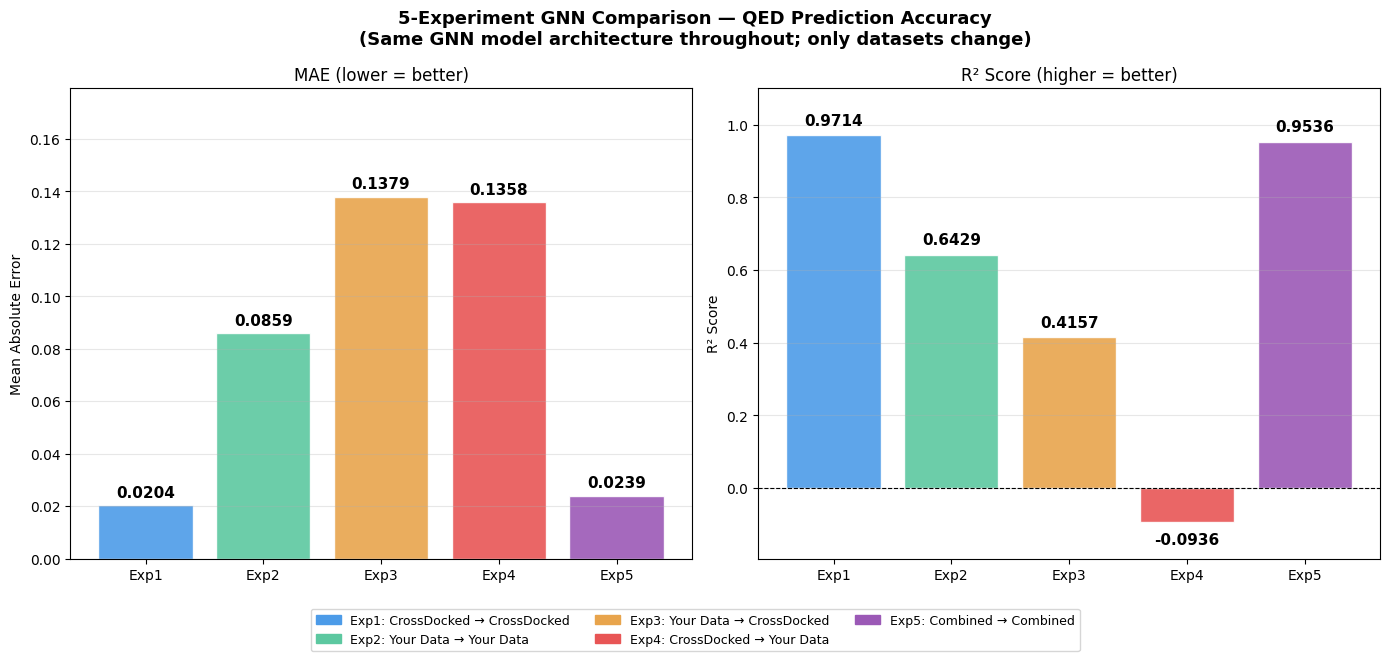

✓ Saved 05_experiment_comparison.png


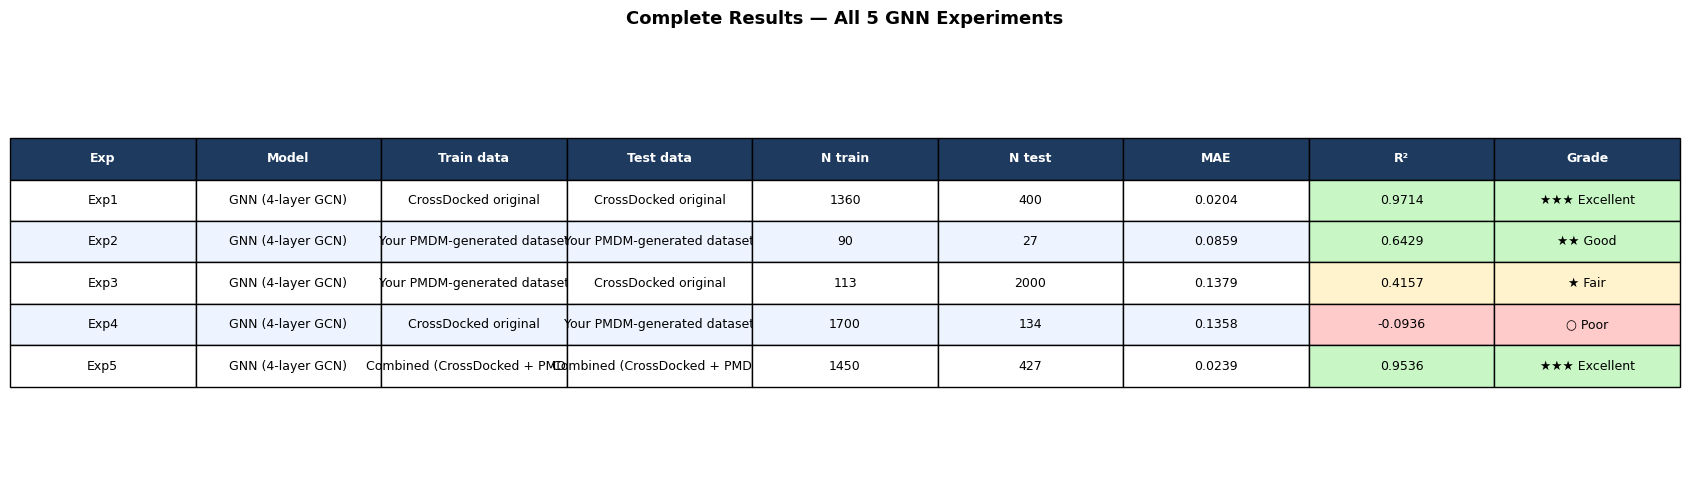

✓ Saved 06_results_table.png

══════════════════════════════════════════════════════════
  FINAL RESULTS — ALL 5 GNN EXPERIMENTS
  (Same GNN model; only dataset changes)
══════════════════════════════════════════════════════════

  Exp1: Train → CrossDocked original
          Test  → CrossDocked original
          MAE=0.0204   R²=0.9714   ★★★ Excellent

  Exp2: Train → Your PMDM-generated dataset
          Test  → Your PMDM-generated dataset
          MAE=0.0859   R²=0.6429   ★★ Good

  Exp3: Train → Your PMDM-generated dataset
          Test  → CrossDocked original
          MAE=0.1379   R²=0.4157   ★ Fair

  Exp4: Train → CrossDocked original
          Test  → Your PMDM-generated dataset
          MAE=0.1358   R²=-0.0936   ○ Poor

  Exp5: Train → Combined (CrossDocked + PMDM)
          Test  → Combined (CrossDocked + PMDM)
          MAE=0.0239   R²=0.9536   ★★★ Excellent
══════════════════════════════════════════════════════════
  Best MAE : Exp1  (0.0204)
  Best R²  : Exp1   (0.9714

In [27]:
# ══════════════════════════════════════════════════════
# CELL 9 — Comparison chart + summary table
# All 5 experiments side by side
# ══════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json, pathlib

BASE    = pathlib.Path('/content/drive/MyDrive/PMDM')
RESULTS = BASE / 'experiment_results'
DEMO    = BASE / 'demo_outputs'
DEMO.mkdir(exist_ok=True)

# Load all 5 result files
fnames = [
    'exp1_gnn_cd_cd.json',
    'exp2_gnn_my_my.json',
    'exp3_gnn_my_cd.json',
    'exp4_gnn_cd_my.json',
    'exp5_gnn_combined.json',
]
exps = []
for fname in fnames:
    p = RESULTS / fname
    if p.exists():
        exps.append(json.loads(p.read_text()))
    else:
        print(f'WARNING: {fname} not found — run cells 4–8 first')

if len(exps) < 5:
    print(f'Only {len(exps)}/5 results found. Run missing experiment cells.')
else:
    labels = [f'Exp{i+1}' for i in range(5)]
    maes   = [e['MAE'] for e in exps]
    r2s    = [e['R2']  for e in exps]

    short_train = [
        'CrossDocked', 'Your Data', 'Your Data', 'CrossDocked', 'Combined'
    ]
    short_test = [
        'CrossDocked', 'Your Data', 'CrossDocked', 'Your Data', 'Combined'
    ]

    colors = ['#4C9BE8', '#5CC8A0', '#E8A44C', '#E85555', '#9B59B6']

    # ── Bar charts ────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(
        '5-Experiment GNN Comparison — QED Prediction Accuracy\n'
        '(Same GNN model architecture throughout; only datasets change)',
        fontsize=13, fontweight='bold'
    )

    # MAE (lower = better)
    bars = axes[0].bar(labels, maes, color=colors, edgecolor='white', alpha=0.9)
    axes[0].set_title('MAE (lower = better)', fontsize=12)
    axes[0].set_ylabel('Mean Absolute Error')
    axes[0].set_ylim(0, max(maes) * 1.3)
    for bar, v in zip(bars, maes):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                     f'{v:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)

    # R² (higher = better)
    bars2 = axes[1].bar(labels, r2s, color=colors, edgecolor='white', alpha=0.9)
    axes[1].set_title('R² Score (higher = better)', fontsize=12)
    axes[1].set_ylabel('R² Score')
    axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_ylim(min(min(r2s)-0.1, -0.1), 1.1)
    for bar, v in zip(bars2, r2s):
        ypos = bar.get_height() + 0.02 if v >= 0 else bar.get_height() - 0.07
        axes[1].text(bar.get_x()+bar.get_width()/2, ypos,
                     f'{v:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)

    # Legend
    patches = [
        mpatches.Patch(color=colors[i],
                       label=f'Exp{i+1}: {short_train[i]} → {short_test[i]}')
        for i in range(5)
    ]
    fig.legend(handles=patches, loc='lower center', ncol=3,
               bbox_to_anchor=(0.5, -0.10), fontsize=9)

    plt.tight_layout()
    plt.savefig(DEMO / '05_experiment_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ Saved 05_experiment_comparison.png')

    # ── Summary table ─────────────────────────────────
    def grade(r2):
        if r2 > 0.8: return '★★★ Excellent'
        if r2 > 0.5: return '★★ Good'
        if r2 > 0.2: return '★ Fair'
        return '○ Poor'

    fig2, ax2 = plt.subplots(figsize=(17, 5))
    ax2.axis('off')

    headers = ['Exp','Model','Train data','Test data',
               'N train','N test','MAE','R²','Grade']
    rows_t = [[
        f'Exp{i+1}',
        'GNN (4-layer GCN)',
        e['train_data'],
        e['test_data'],
        e['n_train'], e['n_test'],
        f"{e['MAE']:.4f}",
        f"{e['R2']:.4f}",
        grade(e['R2'])
    ] for i, e in enumerate(exps)]

    tbl = ax2.table(cellText=rows_t, colLabels=headers,
                    loc='center', cellLoc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 2.2)

    for j in range(len(headers)):
        tbl[0,j].set_facecolor('#1E3A5F')
        tbl[0,j].set_text_props(color='white', fontweight='bold')
    for i in range(1, len(rows_t)+1):
        bg = '#EEF4FF' if i % 2 == 0 else 'white'
        for j in range(len(headers)):
            tbl[i,j].set_facecolor(bg)
        r2v = float(rows_t[i-1][7])
        r2c = '#C8F7C5' if r2v>0.5 else ('#FFF3CD' if r2v>0.2 else '#FECACA')
        tbl[i,7].set_facecolor(r2c)
        tbl[i,8].set_facecolor(r2c)

    ax2.set_title('Complete Results — All 5 GNN Experiments',
                  fontsize=13, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig(DEMO / '06_results_table.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ Saved 06_results_table.png')

    # ── Final printed summary ──────────────────────────
    print(f'\n{"═"*58}')
    print(f'  FINAL RESULTS — ALL 5 GNN EXPERIMENTS')
    print(f'  (Same GNN model; only dataset changes)')
    print(f'{"═"*58}')
    for i, e in enumerate(exps):
        print(f'\n  Exp{i+1}: Train → {e["train_data"]}')
        print(f'          Test  → {e["test_data"]}')
        print(f'          MAE={e["MAE"]:.4f}   R²={e["R2"]:.4f}   {grade(e["R2"])}')
    print(f'{"═"*58}')
    best_mae = min(exps, key=lambda e: e['MAE'])
    best_r2  = max(exps, key=lambda e: e['R2'])
    print(f'  Best MAE : Exp{exps.index(best_mae)+1}  ({best_mae["MAE"]:.4f})')
    print(f'  Best R²  : Exp{exps.index(best_r2)+1}   ({best_r2["R2"]:.4f})')